In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


DATA PREPROCESSING

In [4]:
df = df.dropna(subset=['listed_in', 'rating'])
df = df[['type', 'listed_in', 'release_year', 'rating']]

df['Genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

SIMULATION

In [37]:
import numpy as np

np.random.seed(42)

df['Age'] = np.random.randint(16, 30, size=len(df))
df['Watch_Time'] = np.random.randint(1, 10, size=len(df))

ADVANCED SIMULATION

In [7]:
genre_weights = {
    'Drama': 0.3,
    'Comedy': 0.25,
    'Action': 0.2,
    'Thriller': 0.15,
    'Romance': 0.1
}

df['Preference_Score'] = df['Genre'].map(genre_weights).fillna(0.05)

df['Preference_Score'] += np.random.rand(len(df)) * 0.1

PROBABILITY

In [8]:
prob = df['Genre'].value_counts(normalize=True)
print(prob)

Genre
Dramas                          0.181643
Comedies                        0.137453
Action & Adventure              0.097580
Documentaries                   0.094172
International TV Shows          0.087925
Children & Family Movies        0.068727
Crime TV Shows                  0.045325
Kids' TV                        0.043962
Stand-Up Comedy                 0.037942
Horror Movies                   0.031239
British TV Shows                0.028740
Docuseries                      0.025105
Anime Series                    0.019880
International Movies            0.014540
TV Comedies                     0.013632
Reality TV                      0.013632
Classic Movies                  0.009088
TV Dramas                       0.007611
Thrillers                       0.007384
Movies                          0.006361
TV Action & Adventure           0.004544
Stand-Up Comedy & Talk Shows    0.003862
Romantic TV Shows               0.003635
Classic & Cult TV               0.002499
Anime Feat

STATISTICS

In [9]:
print("Mean Age:", df['Age'].mean())
print("Median Watch Time:", df['Watch_Time'].median())
print("Variance:", df['Watch_Time'].var())

Mean Age: 22.498693627172553
Median Watch Time: 5.0
Variance: 6.64681957719132


PREFERNCES TOP 10 GENRES ONLY

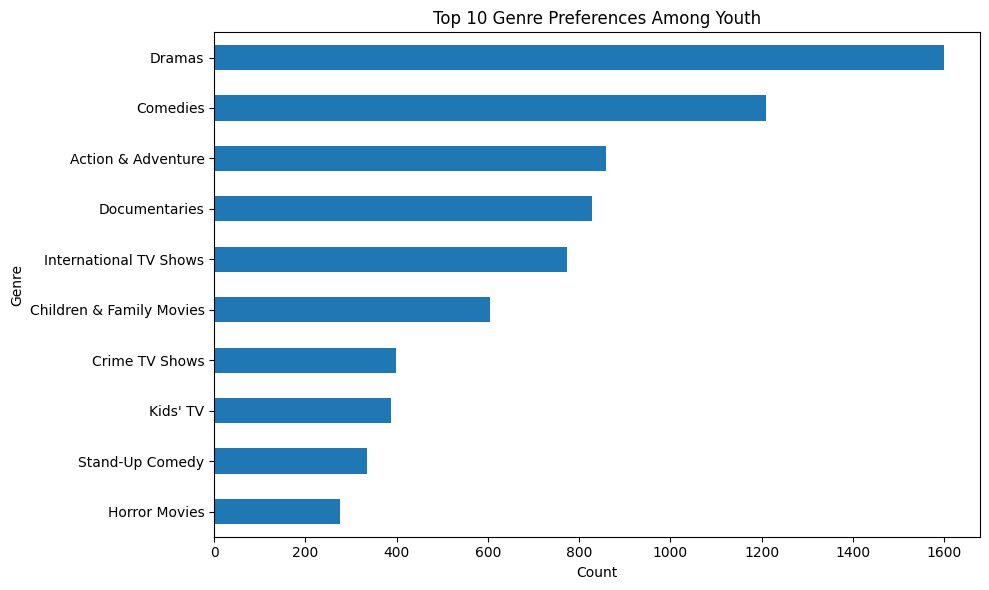

In [16]:
top_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh')

plt.title("Top 10 Genre Preferences Among Youth")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()

plt.show()

Watch Time vs Genre (TOP 8)

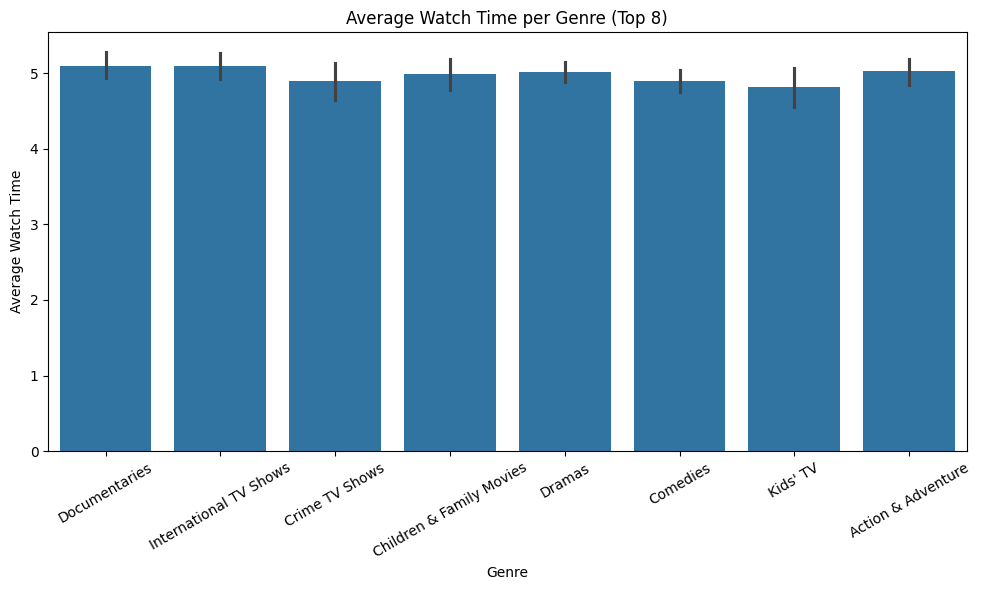

In [20]:
top8 = df['Genre'].value_counts().head(8).index
df_top = df[df['Genre'].isin(top8)]

plt.figure(figsize=(10,6))
sns.barplot(x='Genre', y='Watch_Time', data=df_top)

plt.title("Average Watch Time per Genre (Top 8)")
plt.xlabel("Genre")
plt.ylabel("Average Watch Time")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

AGE DISTRIBUTION

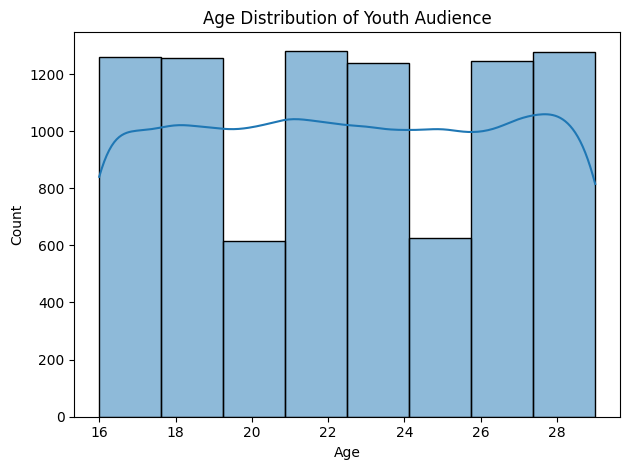

In [22]:
sns.histplot(df['Age'], bins=8, kde=True)

plt.title("Age Distribution of Youth Audience")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Watch Time Distribution (EDA)

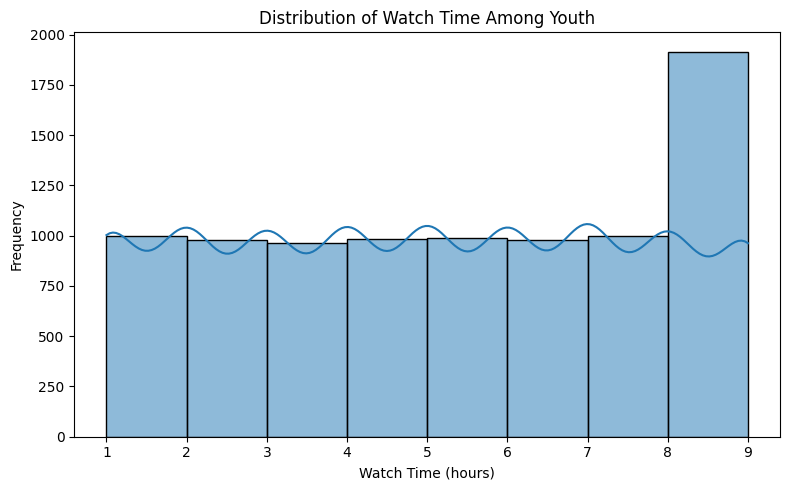

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df['Watch_Time'], bins=8, kde=True)

plt.title("Distribution of Watch Time Among Youth")
plt.xlabel("Watch Time (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Age vs Genre (Box Plot)

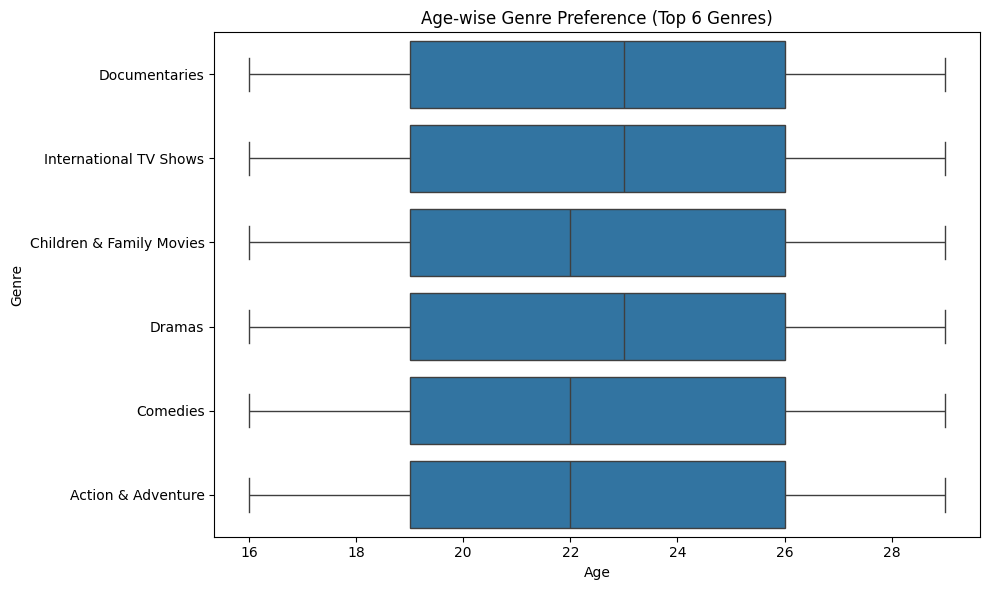

In [41]:
top6 = df['Genre'].value_counts().head(6).index
df_top = df[df['Genre'].isin(top6)]

plt.figure(figsize=(10,6))
sns.boxplot(y='Genre', x='Age', data=df_top)

plt.title("Age-wise Genre Preference (Top 6 Genres)")
plt.xlabel("Age")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

CORRELATION HEATMAP

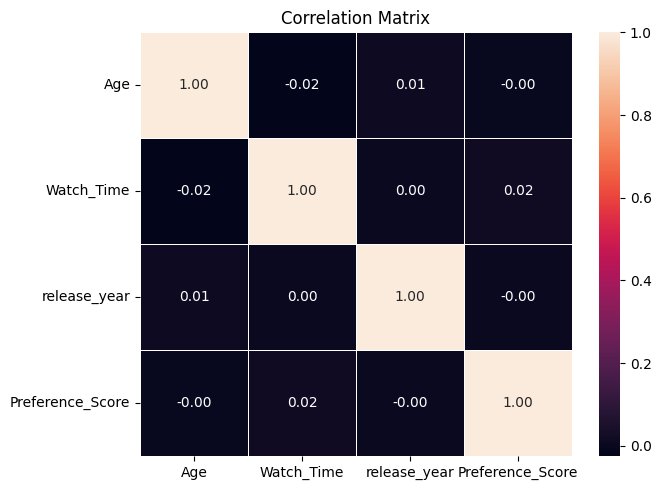

In [23]:
corr = df[['Age','Watch_Time','release_year','Preference_Score']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

PROBABILITY PIE CHART

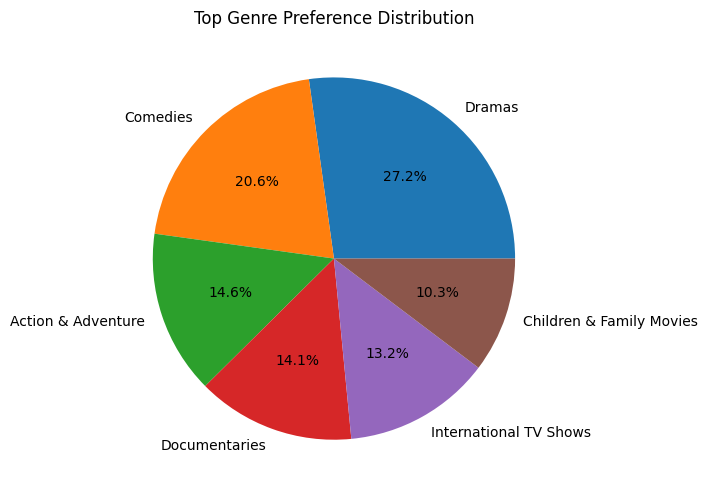

In [24]:
genre_prob = df['Genre'].value_counts(normalize=True).head(6)

plt.figure(figsize=(7,7))
genre_prob.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top Genre Preference Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

AGE GROUP vs GENRE

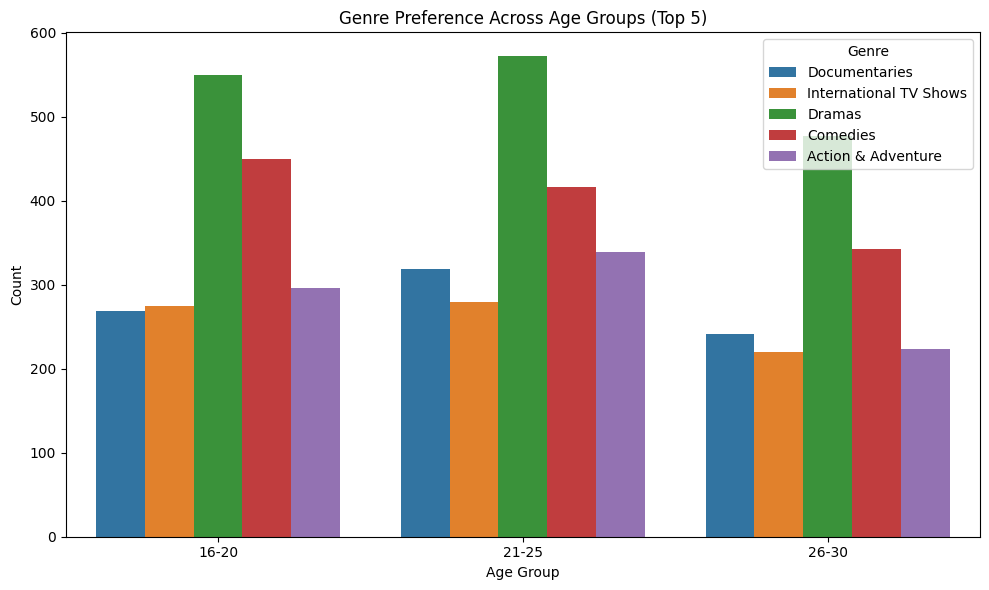

In [25]:
df['Age_Group'] = pd.cut(df['Age'], bins=[15,20,25,30], labels=['16-20','21-25','26-30'])

top5 = df['Genre'].value_counts().head(5).index
df_top = df[df['Genre'].isin(top5)]

plt.figure(figsize=(10,6))
sns.countplot(x='Age_Group', hue='Genre', data=df_top)

plt.title("Genre Preference Across Age Groups (Top 5)")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

Predictions

In [33]:
y_pred = model.predict(X_test)

Prediction genre preference

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Genre_encoded'] = le.fit_transform(df['Genre'])

X = df[['Age', 'Watch_Time', 'release_year']]
y = df['Genre_encoded']

Trained model

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.4934696195343555


High vs Low Preference Target

In [29]:
df['Preference_Label'] = (df['Preference_Score'] > df['Preference_Score'].mean()).astype(int)

df[['Preference_Score', 'Preference_Label']].head()

,Preference_Score,Preference_Label
0,0.087426,0
1,0.138411,1
2,0.116766,1
3,0.070541,0
4,0.081990,0


Defining Features & Target

In [30]:
X = df[['Age', 'Watch_Time', 'release_year']]
y = df['Preference_Label']

Train-Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Confusion Matrix (MODEL PROOF)

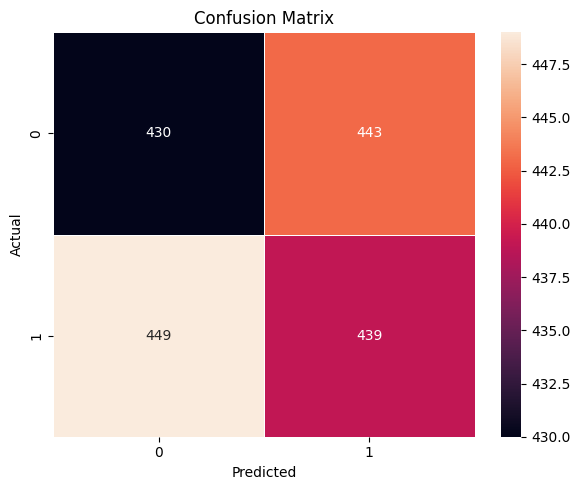

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', linewidths=0.5)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Feature Importance

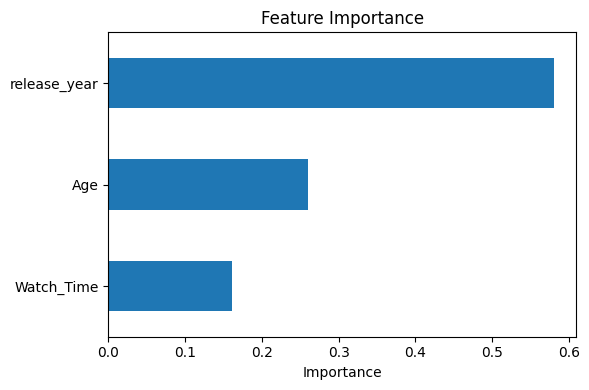

In [36]:
import pandas as pd

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
pd.Series(importance, index=features).sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()